# Stroke Prediction Analysis

## Sprint 2 – Exploratory Data Analysis & Visualization

### Sprint Objective

The objective of Sprint 2 is to perform Exploratory Data Analysis (EDA) on the cleaned healthcare dataset. The analysis focuses on understanding patient characteristics, health and lifestyle factors, relationships between variables, and identifying factors associated with stroke occurrence.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The cleaned healthcare dataset generated during Sprint 1 is loaded into a Pandas DataFrame. Using the cleaned dataset ensures that Sprint 2 analysis is performed on the validated and prepared data without modifying the original dataset.

In [74]:
# Load the cleaned dataset

df = pd.read_csv('stroke_cleaned.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [75]:
print(df.shape)
print(df.isnull().sum())

(5110, 12)
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


## 1. Descriptive Analysis

In [76]:
# Measures of central tendency

print("Mean:")
print(df[['age', 'avg_glucose_level', 'bmi']].mean())

print("\nMedian:")
print(df[['age', 'avg_glucose_level', 'bmi']].median())

print("\nMode:")
print(df[['age', 'avg_glucose_level', 'bmi']].mode().iloc[0])

Mean:
age                   43.226614
avg_glucose_level    106.147677
bmi                   28.862035
dtype: float64

Median:
age                  45.000
avg_glucose_level    91.885
bmi                  28.100
dtype: float64

Mode:
age                  78.00
avg_glucose_level    93.88
bmi                  28.10
Name: 0, dtype: float64


In [12]:
# Measures of Central Tendency

central_tendency = pd.DataFrame({
    'Mean': df[['age', 'avg_glucose_level', 'bmi']].mean(),
    'Median': df[['age', 'avg_glucose_level', 'bmi']].median(),
    'Mode': df[['age', 'avg_glucose_level', 'bmi']].mode().iloc[0]
})

central_tendency

,Mean,Median,Mode
age,43.226614,45.000,78.00
avg_glucose_level,106.147677,91.885,93.88
bmi,28.862035,28.100,28.10


Mean → average value , Median → middle value , Mode → most frequently occurring value

The average age of the patients is around 43 years, with a median age of 45 years. 

The average glucose level is 106.15, while the median is 91.89. 

The average BMI is around 28.86, with a median of 28.10.

The mean glucose level is higher than its median, which suggests that some patients have relatively high glucose values. 
    
The mean and median BMI values are close to each other, showing that the BMI values are more centered around 28.

Mode is simply the most frequently occurring exact value in the data. It's not necessarily the best measure of the "typical" patient.

In [13]:
# Measures of Dispersion

dispersion = pd.DataFrame({
    'Standard Deviation': df[['age', 'avg_glucose_level', 'bmi']].std(),
    'Variance': df[['age', 'avg_glucose_level', 'bmi']].var(),
    'Range': df[['age', 'avg_glucose_level', 'bmi']].max() - df[['age', 'avg_glucose_level', 'bmi']].min()
})

dispersion

,Standard Deviation,Variance,Range
age,22.612647,511.331792,81.92
avg_glucose_level,45.283560,2050.600820,216.62
bmi,7.699562,59.283260,87.30


The age values have a standard deviation of 22.61, showing considerable variation in patient ages.

The avg_glucose_level has a standard deviation of 45.28, indicating a wider spread in glucose levels.

The bmi values have a standard deviation of 7.70, showing less variation compared to age and glucose level.

Among the three numerical variables, avg_glucose_level has the widest spread, followed by age, while BMI has less variation.

In [14]:
# Distribution of numerical variables

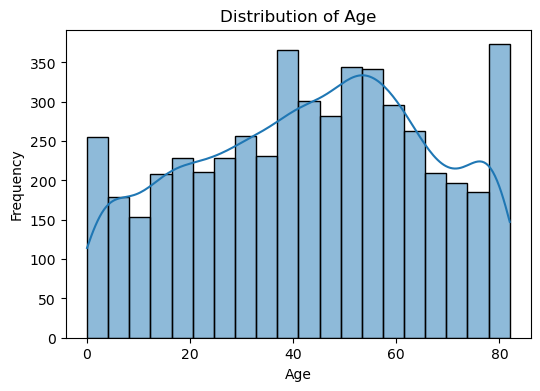

In [15]:
# Distribution of age

plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age values are spread across a wide range. Most patients are between around 20 and 60 years, with fewer patients at some younger ages.

The age distribution is fairly spread out and is close to symmetric, with a slight left skew as we found earlier.

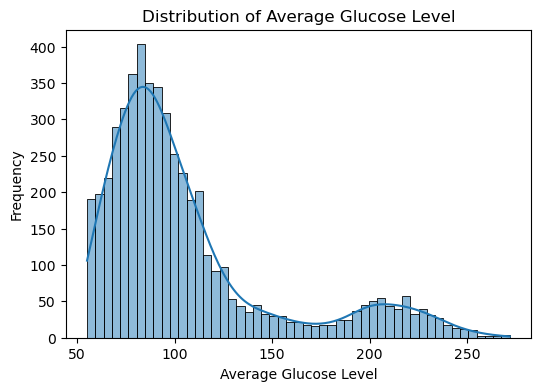

In [16]:
# Distribution of average glucose level

plt.figure(figsize=(6, 4))
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title('Distribution of Average Glucose Level')
plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.show()

Most glucose levels are concentrated around 70 to 120, while some patients have much higher glucose levels.

The distribution is right-skewed, which means a smaller number of patients have high glucose levels.

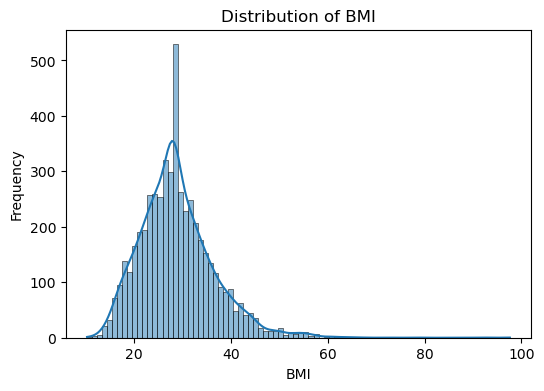

In [17]:
# Distribution of BMI

plt.figure(figsize=(6, 4))
sns.histplot(df['bmi'], kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Most BMI values are concentrated around 20 to 35, while a small number of patients have much higher BMI values.

BMI is right-skewed, with some higher BMI values creating a longer right tail.

Among the three variables, avg_glucose_level and bmi show clear right-skewed distributions, while age is more evenly distributed.

In [18]:
# Summary statistics of numerical variables

df[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000
mean,43.226614,106.147677,28.862035
std,22.612647,45.283560,7.699562
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.800000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,32.800000
max,82.000000,271.740000,97.600000


The dataset contains 5110 records. The average age is 43.23 years, average glucose level is 106.15, and average BMI is 28.86.
    
The values show that age ranges from 0.08 to 82 years, glucose level ranges from 55.12 to 271.74, and BMI ranges from 10.30 to 97.60.

The numerical variables have different ranges and levels of variation. The maximum values of glucose level and BMI are much higher than their median values, which is consistent with the right-skewed distributions observed earlier.

## 2. Univariate Analysis

Univariate analysis means analyzing one feature at a time to understand its characteristics.

### Numerical Variables

Our main numerical variables are :  age , avg_glucose_level , bmi


The distribution of numerical variables was already analyzed using histograms in the Descriptive Analysis section.

In [19]:
# Frequency distribution of numerical variables

frequency_tables = []

for col in ['age', 'avg_glucose_level', 'bmi']:
    temp = pd.cut(df[col], bins=5).value_counts().sort_index().reset_index()
    temp.columns = ['Range', 'Frequency']
    temp['Variable'] = col
    frequency_tables.append(temp)

frequency_table = pd.concat(frequency_tables, ignore_index=True)

frequency_table[['Variable', 'Range', 'Frequency']]

,Variable,Range,Frequency
0,age,"(-0.00192, 16.464]",796
1,age,"(16.464, 32.848]",924
2,age,"(32.848, 49.232]",1180
3,age,"(49.232, 65.616]",1245
4,age,"(65.616, 82.0]",965
5,avg_glucose_level,"(54.903, 98.444]",3040
6,avg_glucose_level,"(98.444, 141.768]",1266
7,avg_glucose_level,"(141.768, 185.092]",245
8,avg_glucose_level,"(185.092, 228.416]",426
9,avg_glucose_level,"(228.416, 271.74]",133


Age : Most patients are concentrated between approximately 33 and 66 years of age.

Glucose : Most patients have glucose levels between 55–98.

BMI : Most patients have BMI values below approximately 45, while very few observations are above 45.

The frequency distribution shows that most patients have moderate age, glucose, and BMI values, while extreme values occur less frequently.

In [20]:
# Calculate skewness of numerical variables

skewness_table = pd.DataFrame({
    'Skewness': df[['age', 'avg_glucose_level', 'bmi']].skew()
})

skewness_table

,Skewness
age,-0.137059
avg_glucose_level,1.572284
bmi,1.088187


Age : Skewness is close to 0, so the distribution is nearly symmetric.
    
Average Glucose Level : Positive skewness indicates a right-skewed distribution.
    
BMI : Positive skewness indicates a right-skewed distribution.

avg_glucose_level is the most right-skewed numerical variable, followed by bmi. Age is approximately symmetric with a slight left skew.

In [21]:
# Calculate outliers using IQR method

outlier_results = []

for col in ['age', 'avg_glucose_level', 'bmi']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outlier_results.append({
        'Variable': col,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Number of Outliers': len(outliers)
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table

,Variable,Lower Limit,Upper Limit,Number of Outliers
0,age,-29.0000,115.0000,0
1,avg_glucose_level,21.9775,169.3575,627
2,bmi,10.3000,46.3000,126


Age : No outliers were detected.
    
Average glucose level : 627 outliers were detected.
    
BMI : 126 outliers were detected.

avg_glucose_level has the highest number of outliers, followed by bmi. Age does not have any outliers according to the IQR method.

The detected outliers are retained because they may represent genuine patient health conditions and could be important for stroke analysis.

In [22]:
# Value counts of stroke

stroke_counts = df['stroke'].value_counts()

stroke_counts

stroke
0    4861
1     249
Name: count, dtype: int64

0 → Did not have a stroke

1 → Had a stroke

4861 patients did not have a stroke. 249 patients had a stroke.

The number of non-stroke patients is much higher than stroke patients.

The target variable stroke is highly imbalanced, with considerably fewer stroke cases than non-stroke cases. The class imbalance should be considered during further analysis because stroke cases are much fewer than non-stroke cases.

### Categorical Variables.

Categorical variables are:

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

We already checked their value counts in Sprint 1, so here in Univariate Analysis we'll focus on their distribution using count plots.

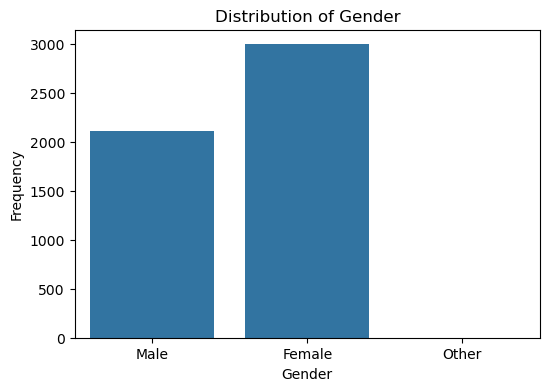

In [23]:
# Distribution of Gender

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

Female patients are higher in number than male patients, while the Other category has only one patient.

The dataset has more female patients compared to male patients.

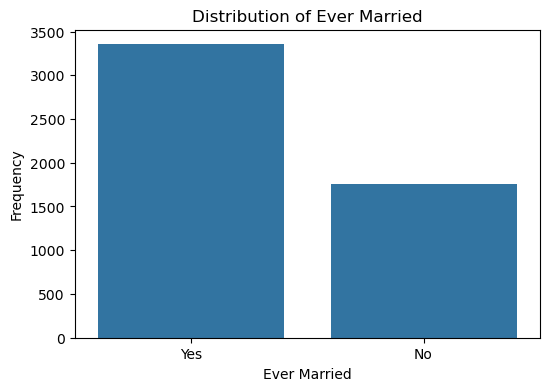

In [24]:
# Distribution of Ever Married

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ever_married')
plt.title('Distribution of Ever Married')
plt.xlabel('Ever Married')
plt.ylabel('Frequency')
plt.show()

The number of patients who are married is higher than those who are not married.

Most patients in the dataset have been married.

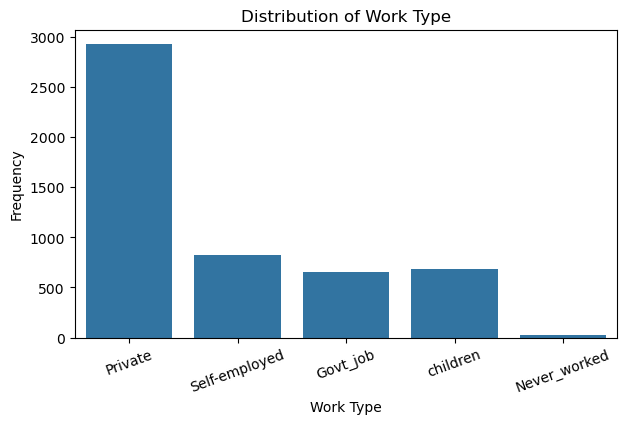

In [25]:
# Distribution of Work Type

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='work_type')
plt.title('Distribution of Work Type')
plt.xlabel('Work Type')
plt.ylabel('Frequency')
plt.xticks(rotation=20)
plt.show()

Private is the most common work type, while Never_worked has very few patients.

Most patients work in the private sector, while very few patients have never worked.

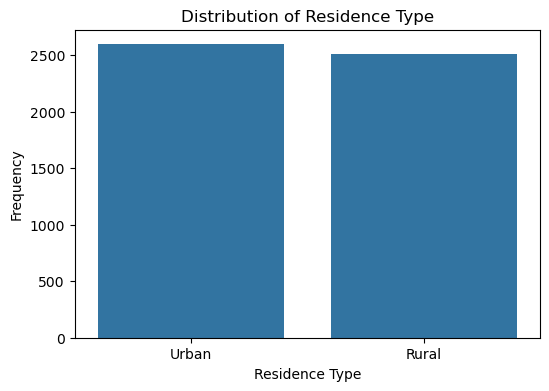

In [26]:
# Distribution of Residence Type

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Residence_type')
plt.title('Distribution of Residence Type')
plt.xlabel('Residence Type')
plt.ylabel('Frequency')
plt.show()

The number of patients from Urban and Rural areas is almost similar.

There is no major difference between Urban and Rural patients in the dataset.

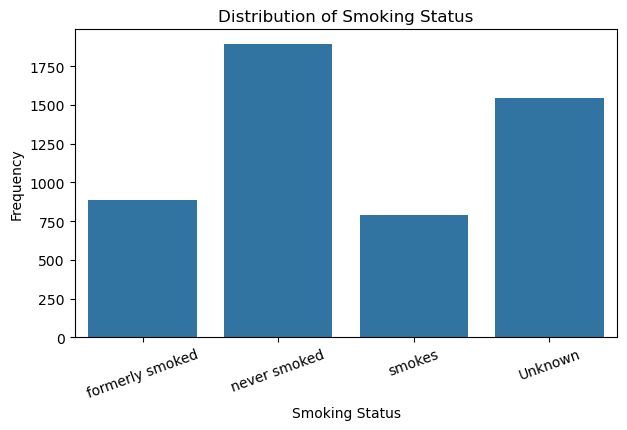

In [27]:
# Distribution of Smoking Status

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='smoking_status')
plt.title('Distribution of Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')
plt.xticks(rotation=20)
plt.show()


never smoked is the most common category, followed by Unknown. smokes and formerly smoked have fewer patients.

Most patients are non-smokers, but a considerable number of smoking-status values are recorded as Unknown.

In [28]:
# Frequency of categorical variables

categorical_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

frequency_tables = []

for col in categorical_cols:
    temp = df[col].value_counts().reset_index()
    temp.columns = ['Category', 'Frequency']
    temp['Variable'] = col
    frequency_tables.append(temp)

categorical_frequency = pd.concat(frequency_tables, ignore_index=True)

categorical_frequency[['Variable', 'Category', 'Frequency']]

,Variable,Category,Frequency
0,gender,Female,2994
1,gender,Male,2115
2,gender,Other,1
3,ever_married,Yes,3353
4,ever_married,No,1757
5,work_type,Private,2925
6,work_type,Self-employed,819
7,work_type,children,687
8,work_type,Govt_job,657
9,work_type,Never_worked,22


Gender : Female patients are the most common.

Ever Married : Most patients are married.

Work Type : Private is the most common work type.

Residence Type : Urban and Rural patients are almost equally distributed.

Smoking Status : never smoked is the most common category.

The categorical variables have different distributions, with some categories occurring much more frequently than others.

#### Class Imbalance

Some categorical features have uneven distributions. In the gender variable, the Other category contains only one record, making it extremely rare. In work_type, the Private category has considerably more records than the Never_worked category.

## 3. Bivariate Analysis

### Numerical vs Numerical

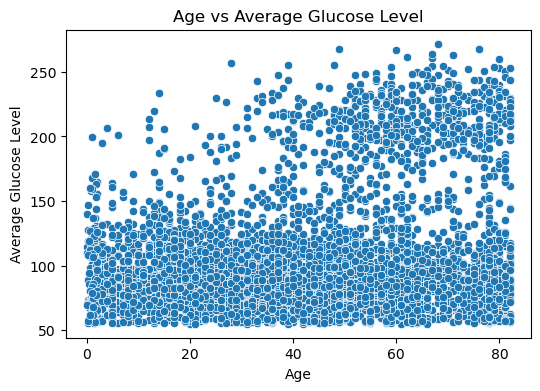

In [29]:
# Age vs Average Glucose Level

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age', y='avg_glucose_level')
plt.title('Age vs Average Glucose Level')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

Age vs Average Glucose Level

The graph shows that glucose levels generally tend to be higher among older patients, although the points are widely scattered.

There appears to be a weak positive relationship between age and average glucose level.

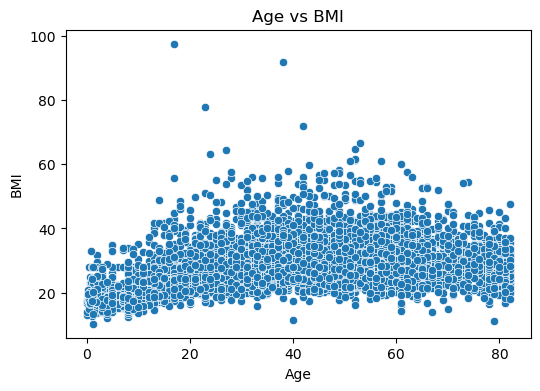

In [30]:
# Age vs BMI

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age', y='bmi')
plt.title('Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

Age vs BMI

BMI values are spread across different age groups. BMI tends to increase slightly with age, but the points are widely scattered.

There is a weak positive relationship between age and BMI.

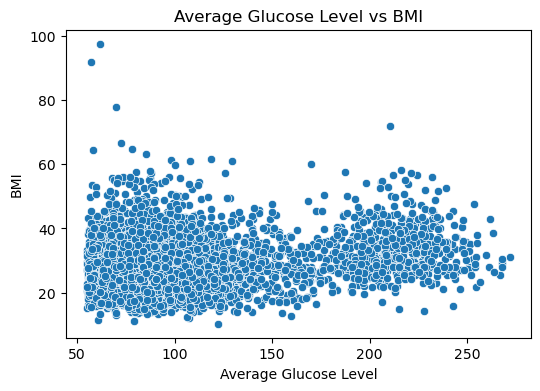

In [31]:
# Average Glucose Level vs BMI

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='avg_glucose_level', y='bmi')
plt.title('Average Glucose Level vs BMI')
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.show()

Average Glucose Level vs BMI

The points are widely scattered without a clear upward or downward pattern.

There appears to be a weak relationship between average glucose level and BMI.


Overall the numerical variables show mostly weak relationships with each other. The relationships are not strong enough to indicate a clear linear pattern.

### Numerical vs Categorical

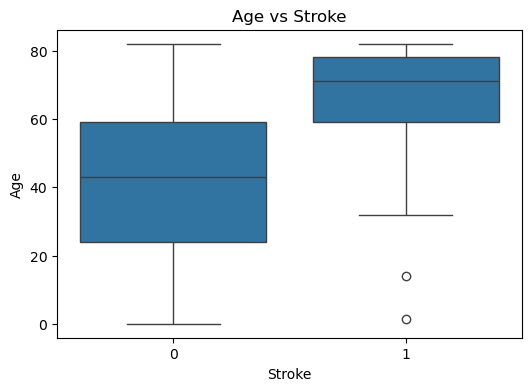

In [32]:
# Age vs Stroke

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='stroke', y='age')
plt.title('Age vs Stroke')
plt.xlabel('Stroke')
plt.ylabel('Age')
plt.show()

Age vs Stroke

Patients who had a stroke generally have higher ages than patients who did not have a stroke.

Age shows a relatively stronger association with stroke compared with the other numerical variables, with stroke patients generally being older.

Business Insight:
Older patients may require greater attention during stroke risk assessment.

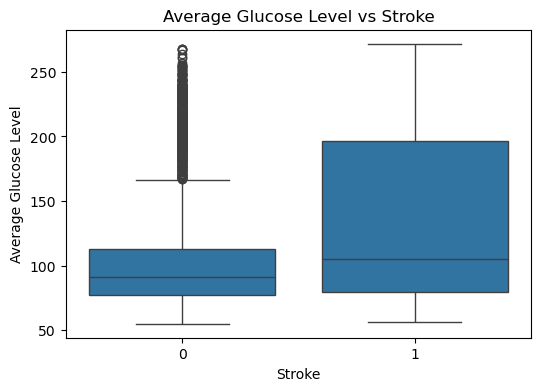

In [33]:
# Average Glucose Level vs Stroke

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Average Glucose Level vs Stroke')
plt.xlabel('Stroke')
plt.ylabel('Average Glucose Level')
plt.show()

Average Glucose Level vs Stroke

Stroke patients generally have higher average glucose levels, and their values show a wider spread.

Higher glucose levels appear to be associated with stroke occurrence.

Business Insight:
Monitoring glucose levels may be useful when identifying patients at higher risk of stroke.

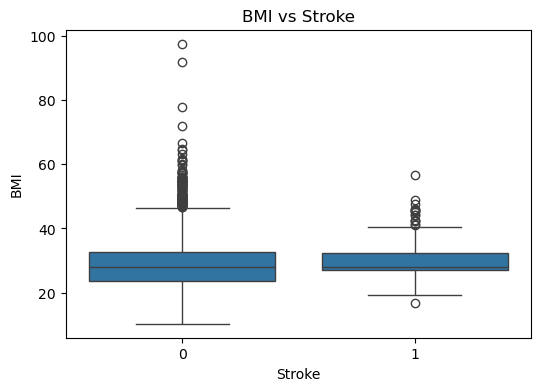

In [34]:
# BMI vs Stroke

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='stroke', y='bmi')
plt.title('BMI vs Stroke')
plt.xlabel('Stroke')
plt.ylabel('BMI')
plt.show()

BMI vs Stroke

The BMI distributions for stroke and non-stroke patients are fairly similar, although stroke patients show some variation and outliers.

BMI does not show a strong difference between stroke and non-stroke groups in this dataset.

Business Insight:
BMI alone may not be a strong indicator of stroke occurrence, so it should be considered along with other factors.

### Categorical vs Categorical

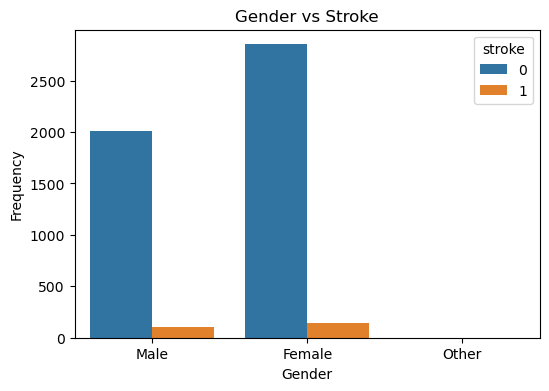

In [40]:
# Gender vs Stroke

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='stroke')
plt.title('Gender vs Stroke')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

Female: 141 stroke cases

Male: 108 stroke cases

Other: 0 stroke cases

Female patients have more stroke cases than male patients in this dataset. However, the overall number of females is also higher.

Business Insight:
Gender can be considered as a factor for further stroke analysis, but the difference should be evaluated along with other health factors.

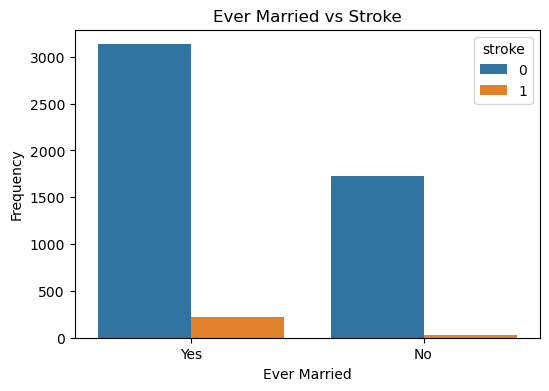

In [41]:
# Ever Married vs Stroke

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ever_married', hue='stroke')
plt.title('Ever Married vs Stroke')
plt.xlabel('Ever Married')
plt.ylabel('Frequency')
plt.show()

Married patients: 220 stroke cases
Unmarried patients: 29 stroke cases

Most stroke cases are found among married patients. However, the married group is also much larger than the unmarried group.

Business Insight:
Marital status alone should not be considered a direct cause of stroke, but it can be examined along with age and other health factors.

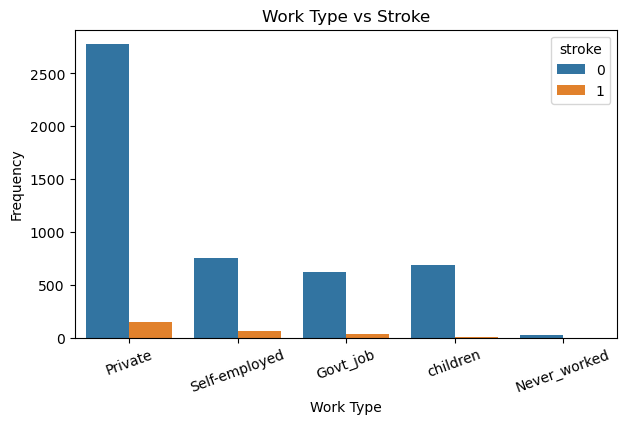

In [42]:
# Work Type vs Stroke

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='work_type', hue='stroke')
plt.title('Work Type vs Stroke')
plt.xlabel('Work Type')
plt.ylabel('Frequency')
plt.xticks(rotation=20)
plt.show()

Private workers have the highest number of stroke cases: 149.

Self-employed patients have 65 stroke cases.

Government employees have 33 stroke cases.

Children have 2 stroke cases.

Never-worked patients have 0 stroke cases.

Stroke cases are highest among private-sector workers, while children and never-worked patients have very few cases.

Business Insight:
Work type may be useful for further analysis, but the different group sizes should be considered before drawing conclusions.

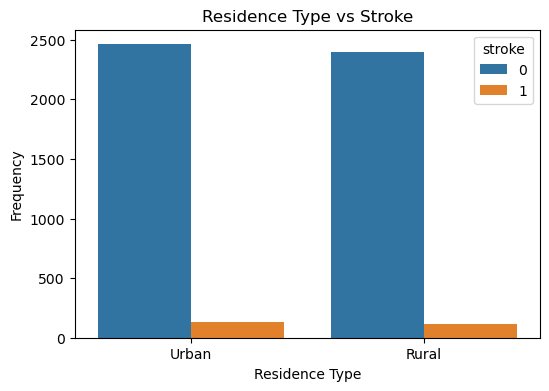

In [43]:
# Residence Type vs Stroke

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Residence_type', hue='stroke')
plt.title('Residence Type vs Stroke')
plt.xlabel('Residence Type')
plt.ylabel('Frequency')
plt.show()

Urban: 135 stroke cases

Rural: 114 stroke cases

The numbers are relatively close.
Urban patients have slightly more stroke cases than rural patients, but the difference is small.

Business Insight:
Residence type shows relatively similar numbers of stroke cases between urban and rural patients. Further analysis using group proportions is needed before drawing conclusions about any association with stroke.

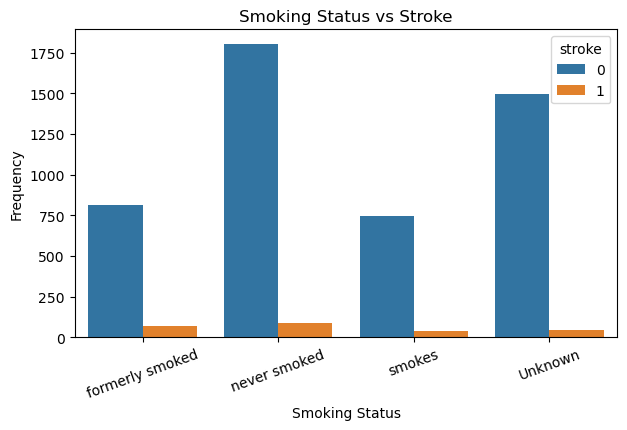

In [44]:
# Smoking Status vs Stroke

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='smoking_status', hue='stroke')
plt.title('Smoking Status vs Stroke')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')
plt.xticks(rotation=20)
plt.show()

Never smoked: 90 stroke cases

Formerly smoked: 70 stroke cases

Unknown: 47 stroke cases

Smokes: 42 stroke cases

The highest number of stroke cases is seen among patients who never smoked, followed by formerly smoked patients.

Business Insight:
Smoking status alone does not clearly explain stroke occurrence because the groups have different numbers of patients. It should be analyzed together with other risk factors.

## 4. Multivariate Analysis

Here we analyze more than two variables together to find hidden patterns related to stroke.
A very useful analysis is to compare age, glucose, BMI, and stroke together.

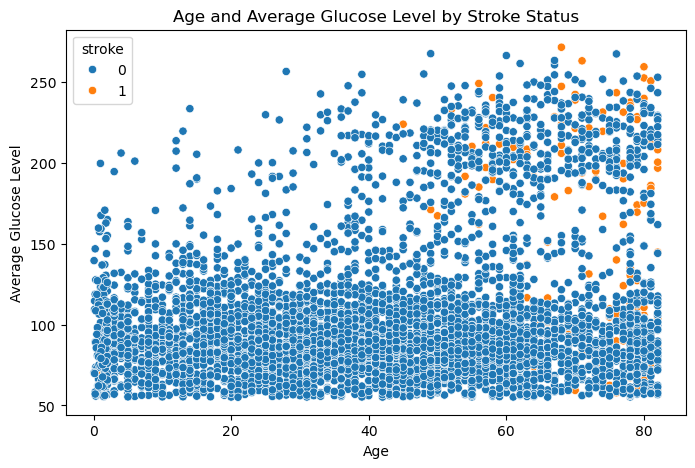

In [45]:
# Age + Average Glucose Level + Stroke

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    hue='stroke'
)

plt.title('Age and Average Glucose Level by Stroke Status')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

Stroke cases are more visible among older patients, especially those with higher average glucose levels.

The combination of higher age and higher glucose level appears to be associated with stroke occurrence in this dataset.

Business Insight
Older patients with elevated glucose levels may require closer monitoring for stroke risk.

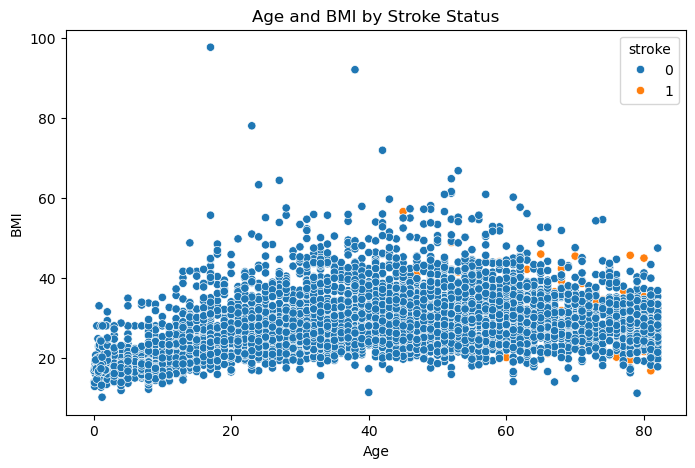

In [46]:
# Age + BMI + Stroke

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='bmi',
    hue='stroke'
)

plt.title('Age and BMI by Stroke Status')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

BMI generally increases from younger ages and becomes more spread out in middle and older age groups.

Stroke cases are mostly seen among older patients, but they are scattered across different BMI values.

Business Insight:
Age may be more useful than BMI alone when identifying patients who may require closer stroke-risk monitoring.

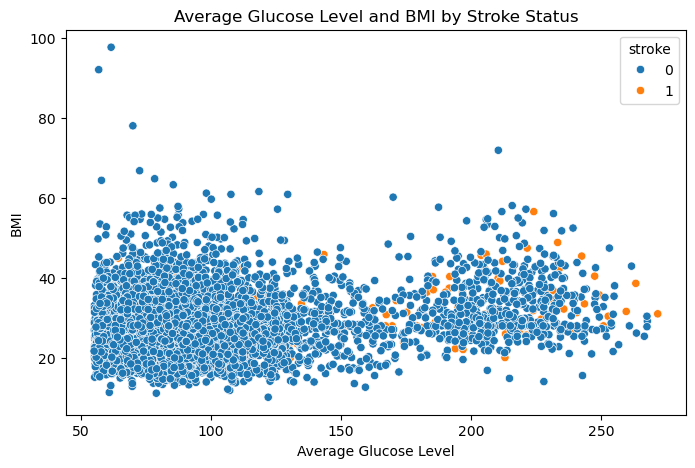

In [47]:
# Average Glucose Level + BMI + Stroke

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='avg_glucose_level',
    y='bmi',
    hue='stroke'
)

plt.title('Average Glucose Level and BMI by Stroke Status')
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.show()

BMI values are widely distributed across glucose levels.

Stroke cases appear more frequently at higher glucose levels.

There is no clear pattern showing that higher BMI alone is strongly associated with stroke.

Business Insight:
Monitoring glucose levels may be more useful than relying on BMI alone when assessing stroke risk.

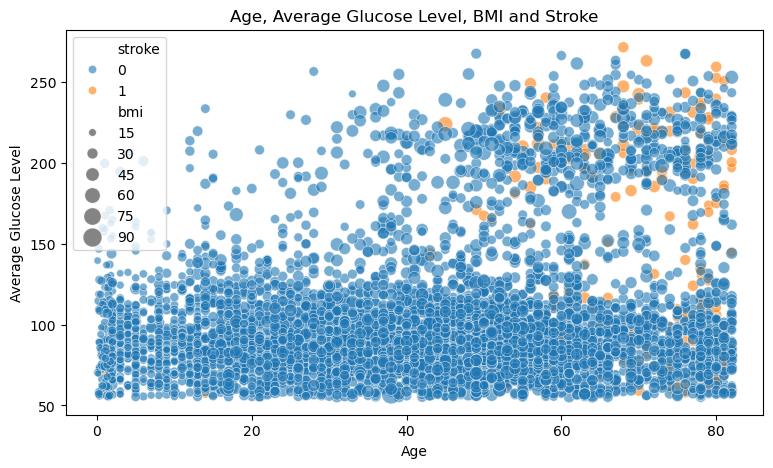

In [48]:
# Age + Glucose + BMI + Stroke

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    size='bmi',
    hue='stroke',
    sizes=(20, 200),
    alpha=0.6
)

plt.title('Age, Average Glucose Level, BMI and Stroke')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

Stroke cases are more visible among older patients and at higher glucose levels.
BMI varies across these patients and does not show a clear pattern with stroke.

When age, glucose level, and BMI are considered together, age and glucose level appear to be more important factors associated with stroke, while BMI shows a weaker relationship.

Business Insight:
Healthcare professionals may benefit from considering multiple patient characteristics together, particularly age and glucose level, rather than relying on a single variable.

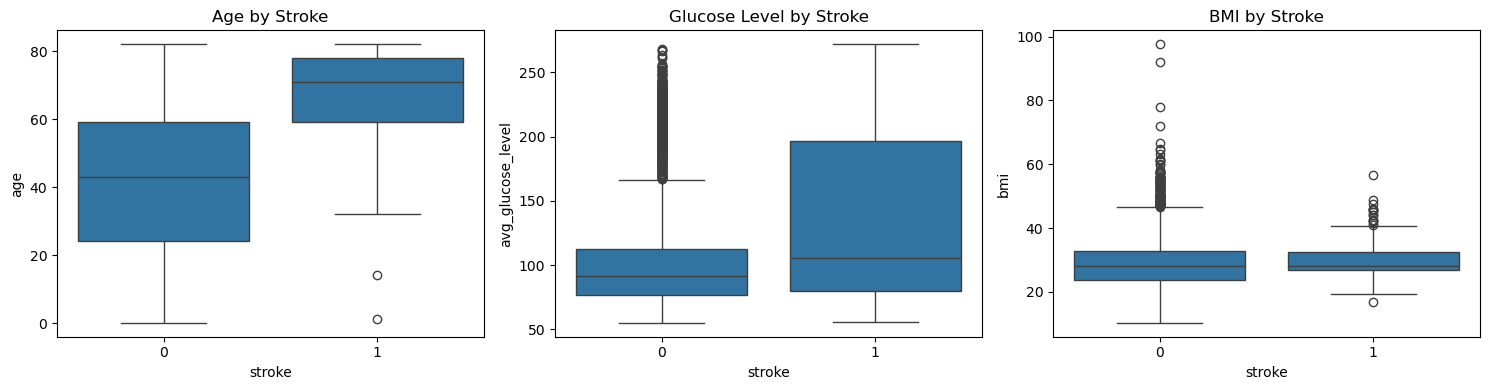

In [49]:
# Numerical Variables by Stroke

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='stroke', y='age', ax=axes[0])
axes[0].set_title('Age by Stroke')

sns.boxplot(data=df, x='stroke', y='avg_glucose_level', ax=axes[1])
axes[1].set_title('Glucose Level by Stroke')

sns.boxplot(data=df, x='stroke', y='bmi', ax=axes[2])
axes[2].set_title('BMI by Stroke')

plt.tight_layout()
plt.show()

Stroke patients generally have higher ages.
Stroke patients show a wider range of average glucose levels.
BMI distributions are relatively similar between stroke and non-stroke groups.

Age and average glucose level show clearer differences between stroke and non-stroke patients, while BMI shows less difference.

Business Insight:
Age and average glucose level show stronger differences between stroke and non-stroke groups in this dataset and may be useful variables for further stroke-risk analysis.

### 5. Group-Based Analysis: Stroke Status

The dataset is grouped by the target variable `stroke` to compare the average age, average glucose level, and BMI of patients with and without stroke.

In [50]:
# Group-based analysis by stroke status

stroke_group = df.groupby('stroke')[['age', 'avg_glucose_level', 'bmi']].mean()
stroke_group

,age,avg_glucose_level,bmi
stroke,,,
0,41.971545,104.795513,28.799115
1,67.728193,132.544739,30.090361


Patients with stroke have a higher average age (67.73 years) compared to non-stroke patients (41.97 years).

Stroke patients have a higher average glucose level (132.54) compared to non-stroke patients (104.80).

The average BMI is also slightly higher for stroke patients (30.09) compared to non-stroke patients (28.80).

Stroke patients are generally older and have higher average glucose levels, while the difference in BMI is relatively small.


In [51]:
# Group-based analysis by gender

gender_group = df.groupby('gender')[['age', 'avg_glucose_level', 'bmi', 'stroke']].mean()
gender_group

,age,avg_glucose_level,bmi,stroke
gender,,,,
Female,43.757395,104.057809,29.034469,0.047094
Male,42.483385,109.088520,28.620993,0.051064
Other,26.000000,143.330000,22.400000,0.000000


Female and male patients have a similar average age, with females at 43.76 years and males at 42.48 years. Males have a slightly higher average glucose level (109.09) compared to females (104.06), while females have a slightly higher average BMI (29.03) than males (28.62). The stroke rate is also slightly higher among males (5.11%) than females (4.71%). The Other category has only one patient, so it is not reliable for comparison.

Overall, male and female patients show similar patterns in age and BMI, with only small differences in glucose level and stroke rate. The small difference in stroke rate suggests that gender does not have a major difference in stroke occurrence in this dataset.

In [52]:
# Group-based analysis by marital status

married_group = df.groupby('ever_married')[['age', 'avg_glucose_level', 'bmi', 'stroke']].mean()
married_group

,age,avg_glucose_level,bmi,stroke
ever_married,,,,
No,22.014229,96.44815,25.300114,0.016505
Yes,54.342082,111.23031,30.728512,0.065613


Married patients have a much higher average age (54.34 years) than unmarried patients (22.01 years). They also have higher average glucose (111.23 vs 96.45) and BMI (30.73 vs 25.30). The stroke rate is higher among married patients (6.56%) compared to unmarried patients (1.65%).

Married patients show higher age, glucose level, BMI, and stroke rate. However, age is an important factor to consider, because married patients are much older on average, which may contribute to their higher stroke rate.

In [53]:
# Group-based analysis by work type

work_group = df.groupby('work_type')[['age', 'avg_glucose_level', 'bmi', 'stroke']].mean()
work_group

,age,avg_glucose_level,bmi,stroke
work_type,,,,
Govt_job,50.879756,107.779772,30.422527,0.050228
Never_worked,16.181818,96.042727,25.545455,0.000000
Private,45.503932,106.796844,30.218701,0.050940
Self-employed,60.201465,112.645446,30.098413,0.079365
children,6.841339,94.400277,20.225764,0.002911


Self-employed patients have the highest stroke rate (7.94%).
Private and Government workers have similar stroke rates, around 5%.
Never-worked patients have 0% stroke rate.
Children have a very low stroke rate (0.29%).
Self-employed patients also have the highest average age (60.20 years).


Self-employed patients show the highest stroke rate, but they also have the highest average age. Therefore, the higher stroke rate may be related to age rather than work type alone.

In [54]:
# Group-based analysis by smoking status

smoking_group = df.groupby('smoking_status')[['age', 'avg_glucose_level', 'bmi', 'stroke']].mean()
smoking_group

,age,avg_glucose_level,bmi,stroke
smoking_status,,,,
Unknown,30.229922,99.601541,25.762500,0.030440
formerly smoked,54.929944,112.886079,30.603616,0.079096
never smoked,46.744715,107.558092,29.942759,0.047569
smokes,47.096324,108.017440,30.382510,0.053232


Formerly smoked patients have the highest stroke rate (7.91%), followed by those who currently smoke (5.32%) and never smoked (4.76%). The formerly smoked group also has the highest average age (54.93 years), while the Unknown group has the lowest average age (30.23 years) and stroke rate (3.04%).

Stroke rates are higher among patients with a history of smoking, especially those who formerly smoked. However, the formerly smoked group is also older on average, so age may contribute to the higher stroke rate.


In [55]:
# Group-based analysis by residence type

residence_group = df.groupby('Residence_type')[['age', 'avg_glucose_level', 'bmi', 'stroke']].mean()
residence_group

,age,avg_glucose_level,bmi,stroke
Residence_type,,,,
Rural,42.900811,106.375235,28.864200,0.045346
Urban,43.542126,105.927307,28.859938,0.052003


Urban and rural patients have very similar average age (43.54 vs 42.90 years) and BMI (28.86 vs 28.86). The average glucose levels are also almost the same (105.93 urban vs 106.38 rural). The stroke rate is slightly higher in urban patients (5.20%) than rural patients (4.53%).

Residence type shows only a small difference in stroke rate, while the other numerical characteristics are nearly the same between rural and urban patients.


## 6. Pivot Table Analysis

Pivot tables are used to compare key health characteristics across different patient groups. The analysis includes average age, average glucose level, average BMI, and stroke rate for each category.

Since the stroke variable is binary (0 = no stroke, 1 = stroke), its mean represents the proportion of patients in that group who had a recorded stroke.

In [56]:
# Pivot Table: Gender and Stroke

pivot_gender = pd.pivot_table(
    df,
    index='gender',
    values=['age', 'avg_glucose_level', 'bmi', 'stroke'],
    aggfunc='mean'
)
pivot_gender

,age,avg_glucose_level,bmi,stroke
gender,,,,
Female,43.757395,104.057809,29.034469,0.047094
Male,42.483385,109.088520,28.620993,0.051064
Other,26.000000,143.330000,22.400000,0.000000


Female and male patients have similar average ages (43.76 and 42.48 years) and BMI (29.03 and 28.62). Males have a slightly higher average glucose level (109.09) and stroke rate (5.11%) compared to females (104.06 and 4.71%). The Other category has only one patient, so it is not suitable for comparison.

Gender shows only a small difference in stroke rate. Male patients have slightly higher glucose levels and stroke rates, while age and BMI are quite similar between males and females.

In [57]:
# Pivot Table: Work Type

pivot_work = pd.pivot_table(
    df,
    index='work_type',
    values=['age', 'avg_glucose_level', 'bmi', 'stroke'],
    aggfunc='mean'
)
pivot_work

,age,avg_glucose_level,bmi,stroke
work_type,,,,
Govt_job,50.879756,107.779772,30.422527,0.050228
Never_worked,16.181818,96.042727,25.545455,0.000000
Private,45.503932,106.796844,30.218701,0.050940
Self-employed,60.201465,112.645446,30.098413,0.079365
children,6.841339,94.400277,20.225764,0.002911


Self-employed patients have the highest average age (60.20 years), glucose level (112.65), and stroke rate (7.94%). Children and never-worked patients have much lower average age, glucose level, BMI, and stroke rates. Private and government employees have similar stroke rates of around 5%.

The higher stroke rate among self-employed patients may be related to their higher average age and glucose levels. Work type alone may not explain stroke occurrence.

In [58]:
# Pivot Table: Smoking Status

pivot_smoking = pd.pivot_table(
    df,
    index='smoking_status',
    values=['age', 'avg_glucose_level', 'bmi', 'stroke'],
    aggfunc='mean'
)
pivot_smoking

,age,avg_glucose_level,bmi,stroke
smoking_status,,,,
Unknown,30.229922,99.601541,25.762500,0.030440
formerly smoked,54.929944,112.886079,30.603616,0.079096
never smoked,46.744715,107.558092,29.942759,0.047569
smokes,47.096324,108.017440,30.382510,0.053232


Formerly smoked patients have the highest average age (54.93 years) and the highest stroke rate (7.91%). They also have the highest average glucose level (112.89) and BMI (30.60). The Unknown group has the lowest average age (30.23 years) and stroke rate (3.04%).

Formerly smoked patients show a higher stroke rate, but their higher average age may also contribute to this difference. Smoking status should therefore be considered together with age and other health factors.

In [59]:
# Pivot Table: Residence Type

pivot_residence = pd.pivot_table(
    df,
    index='Residence_type',
    values=['age', 'avg_glucose_level', 'bmi', 'stroke'],
    aggfunc='mean'
)
pivot_residence

,age,avg_glucose_level,bmi,stroke
Residence_type,,,,
Rural,42.900811,106.375235,28.864200,0.045346
Urban,43.542126,105.927307,28.859938,0.052003


Rural and urban patients have very similar average age (42.90 vs 43.54 years) and BMI (28.86 for both). Their average glucose levels are also almost the same (106.38 rural vs 105.93 urban). The stroke rate is slightly higher in urban patients (5.20%) than rural patients (4.53%).

Residence type shows only a small difference in stroke rate, while age, glucose level, and BMI are almost the same between rural and urban patients.

In [60]:
# Pivot Table: Marital Status

pivot_married = pd.pivot_table(
    df,
    index='ever_married',
    values=['age', 'avg_glucose_level', 'bmi', 'stroke'],
    aggfunc='mean'
)
pivot_married

,age,avg_glucose_level,bmi,stroke
ever_married,,,,
No,22.014229,96.44815,25.300114,0.016505
Yes,54.342082,111.23031,30.728512,0.065613


Married patients have higher average age (54.34 years), glucose level (111.23), and BMI (30.73) compared to unmarried patients (22.01, 96.45, and 25.30). The stroke rate is also higher among married patients (6.56%) than unmarried patients (1.65%).

Married patients show a higher stroke rate, but they are also much older on average. Therefore, age may be an important factor behind this difference, rather than marital status alone.

## 7. Crosstab Analysis

Crosstab analysis is used to examine relationships between categorical variables and compare stroke occurrence across different patient groups.

In [61]:
# Crosstab: Gender vs Stroke

gender_stroke = pd.crosstab(
    df['gender'],
    df['stroke']
)
gender_stroke

stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


In [62]:
# Row-wise percentage

gender_stroke_percent = pd.crosstab(
    df['gender'],
    df['stroke'],
    normalize='index'
) * 100
gender_stroke_percent.round(2)

stroke,0,1
gender,,
Female,95.29,4.71
Male,94.89,5.11
Other,100.00,0.00


Female patients have 141 stroke cases (4.71%), while male patients have 108 stroke cases (5.11%). Although the number of stroke cases is higher among females, the stroke percentage is slightly higher among males. The Other category contains only one patient, so it is not suitable for comparison.

The stroke rate is very similar for males and females, with only a small difference. Therefore, gender does not show a strong difference in stroke occurrence in this dataset.

In [63]:
# Crosstab: Ever Married vs Stroke

married_stroke = pd.crosstab(
    df['ever_married'],
    df['stroke']
)
married_stroke

stroke,0,1
ever_married,,
No,1728,29
Yes,3133,220


In [64]:
# Row-wise percentage

married_stroke_percent = pd.crosstab(
    df['ever_married'],
    df['stroke'],
    normalize='index'
) * 100
married_stroke_percent.round(2)

stroke,0,1
ever_married,,
No,98.35,1.65
Yes,93.44,6.56


Among unmarried patients, 29 (1.65%) experienced a stroke, while among married patients, 220 (6.56%) experienced a stroke. The majority of both groups did not experience a stroke, but the stroke percentage is considerably higher among married patients.

Married patients show a higher stroke rate than unmarried patients. However, this difference may be influenced by age, since married patients have a much higher average age in this dataset.

In [65]:
# Crosstab: Work Type vs Stroke

work_stroke = pd.crosstab(
    df['work_type'],
    df['stroke']
)
work_stroke

stroke,0,1
work_type,,
Govt_job,624,33
Never_worked,22,0
Private,2776,149
Self-employed,754,65
children,685,2


In [66]:
# Row-wise percentage

work_stroke_percent = pd.crosstab(
    df['work_type'],
    df['stroke'],
    normalize='index'
) * 100
work_stroke_percent.round(2)

stroke,0,1
work_type,,
Govt_job,94.98,5.02
Never_worked,100.00,0.00
Private,94.91,5.09
Self-employed,92.06,7.94
children,99.71,0.29


Self-employed patients have the highest stroke rate (7.94%), followed by Private (5.09%) and Government employees (5.02%). Children have a very low stroke rate (0.29%), while the Never-worked group has 0% stroke cases.

Stroke occurrence varies across work types, with self-employed patients showing the highest rate. However, this may be influenced by age, as self-employed patients have a much higher average age than children and never-worked patients.

In [67]:
# Crosstab: Smoking Status vs Stroke

smoking_stroke = pd.crosstab(
    df['smoking_status'],
    df['stroke']
)
smoking_stroke

stroke,0,1
smoking_status,,
Unknown,1497,47
formerly smoked,815,70
never smoked,1802,90
smokes,747,42


In [68]:
# Row-wise percentage

smoking_stroke_percent = pd.crosstab(
    df['smoking_status'],
    df['stroke'],
    normalize='index'
) * 100
smoking_stroke_percent.round(2)

stroke,0,1
smoking_status,,
Unknown,96.96,3.04
formerly smoked,92.09,7.91
never smoked,95.24,4.76
smokes,94.68,5.32


The formerly smoked group has the highest stroke rate (7.91%), followed by those who currently smoke (5.32%) and never smoked (4.76%). The Unknown group has the lowest stroke rate (3.04%).

Patients who formerly smoked show a higher stroke rate than the other smoking categories. However, the formerly smoked group is also older on average, so age may partly explain this difference.

In [69]:
# Crosstab: Residence Type vs Stroke

residence_stroke = pd.crosstab(
    df['Residence_type'],
    df['stroke']
)
residence_stroke

stroke,0,1
Residence_type,,
Rural,2400,114
Urban,2461,135


In [70]:
# Row-wise percentage

residence_stroke_percent = pd.crosstab(
    df['Residence_type'],
    df['stroke'],
    normalize='index'
) * 100
residence_stroke_percent.round(2)

stroke,0,1
Residence_type,,
Rural,95.47,4.53
Urban,94.80,5.20


Rural patients have 114 stroke cases (4.53%), while urban patients have 135 stroke cases (5.20%). Most patients in both groups did not experience a stroke, and the difference in stroke percentage between rural and urban patients is small.


Urban patients show a slightly higher stroke rate than rural patients, but the difference is not large enough to suggest a strong relationship between residence type and stroke occurrence.

## 8. Correlation & Relationship Analysis

Correlation analysis is used to examine the strength and direction of relationships among numerical variables and identify how variables such as age, glucose level, BMI, and stroke are related.

In [71]:
# Correlation matrix for numerical variables

corr_matrix = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].corr()
corr_matrix.round(2)

,age,avg_glucose_level,bmi,stroke
age,1.00,0.24,0.32,0.25
avg_glucose_level,0.24,1.00,0.17,0.13
bmi,0.32,0.17,1.00,0.04
stroke,0.25,0.13,0.04,1.00


Observation

The strongest positive correlation is between age and BMI (0.32), followed by age and stroke (0.25) and age and average glucose level (0.24). Average glucose level and BMI have a weak positive correlation (0.17), while BMI and stroke have a very weak correlation (0.04).

Interpretation

Age has the strongest relationship with stroke (0.25) among the numerical variables, suggesting that older patients are more likely to have experienced a stroke. Average glucose level also has a weak positive relationship with stroke (0.13), while BMI has almost no linear relationship with stroke (0.04). There are no strong negative correlations in the dataset.

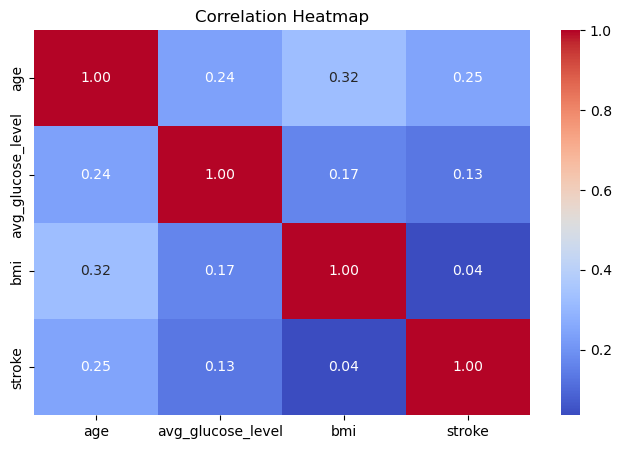

In [72]:
# Correlation Heatmap

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

Heatmap Observation

The heatmap shows that age has the strongest positive correlation with stroke (0.25) among the numerical variables. Age also has a weak positive relationship with BMI (0.32) and average glucose level (0.24). Average glucose level has a weak positive correlation with stroke (0.13), while BMI has a very weak correlation with stroke (0.04). No strong negative correlations are observed.

Interpretation

Overall, age appears to have the strongest numerical association with stroke in this dataset. Glucose level shows a weak relationship with stroke, while BMI has very little linear association. The correlations are relatively weak, so these variables should be considered together with other factors when understanding stroke risk.

## 9. Data Visualization

| Visualization                  | Purpose                                                                                                                         |
| ------------------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| **Histograms**                 | Analyze the distribution of numerical variables such as age, average glucose level, and BMI                                     |
| **Count Plots**                | Analyze the distribution of categorical variables such as gender, work type, marital status, residence type, and smoking status |
| **Box Plots**                  | Compare numerical variables between stroke and non-stroke groups and identify potential outliers                                |
| **Scatter Plots**              | Examine relationships between age, glucose level, and BMI                                                                       |
| **Grouped Scatter Plots**      | Compare numerical relationships based on stroke status                                                                          |
| **Multivariable Scatter Plot** | Analyze age, glucose level, BMI, and stroke together                                                                            |
| **Correlation Heatmap**        | Visualize the strength and direction of correlations among numerical variables                                                  |


Observation

The graphs show clear differences in age and average glucose level between stroke and non-stroke patients. Some outliers are also seen in glucose level and BMI. The categorical graphs show differences in category sizes, while scatter plots show relationships between numerical variables. The heatmap shows that age has the strongest relationship with stroke.

Interpretation

Overall, the graphs support our previous findings. Age and average glucose level are more related to stroke, while BMI has a weaker relationship. The graphs also help us identify outliers, skewness, and uneven category distributions.

## 10. Visual Storytelling

The visualizations are used to explain important patterns in the dataset. Each visualization is connected to a finding and helps understand factors related to stroke occurrence.

### Age Distribution

Most patients are adults and older adults, with fewer very young patients.

Age is an important variable because older patients show a higher association with stroke.

Age-based analysis can help identify patient groups that may need more attention for stroke prevention.

### Average Glucose Level

Most glucose levels are concentrated in the lower range, while some patients have much higher glucose levels.

Glucose level is right-skewed and shows a positive relationship with stroke.

Patients with higher glucose levels may require closer monitoring as part of stroke-risk management.

### BMI

Most BMI values are between around 20 and 35, with some unusually high values.

BMI has a very weak correlation with stroke compared with age and glucose level.

BMI alone may not be a strong indicator of stroke in this dataset and should be considered with other health factors.

### Categorical Variables

The count plots show uneven distributions across categories such as work type, smoking status, and marital status.

Some categories contain many more patients than others, which should be considered when comparing stroke rates.

Category size should be considered before making conclusions about which groups have higher stroke risk.

### Numerical Variables vs Stroke

Stroke patients generally have higher average age and glucose levels than non-stroke patients.

Age and glucose level show stronger relationships with stroke than BMI.

Age and average glucose level show stronger relationships with stroke in this dataset and may be useful variables for further stroke-risk analysis.

### Correlation Heatmap

Age has the strongest correlation with stroke (0.25), followed by average glucose level (0.13). BMI has a very weak correlation with stroke (0.04).

Age has the strongest numerical association with stroke, while BMI has very little linear relationship.

Stroke analysis should give more attention to age and glucose level while considering BMI and other factors together.

 Overall Visual Story :

The visualizations show that age and average glucose level are more closely associated with stroke, while BMI has a weaker relationship. The categorical and distribution graphs also reveal uneven group sizes and outliers. These findings can help identify important factors for further stroke-risk analysis.

## 11. Business Insights

### Major Findings
Age is the most important numerical factor related to stroke. Stroke patients have a much higher average age than non-stroke patients.
Average glucose level is also higher among stroke patients and has a weak positive relationship with stroke.

BMI has a very weak relationship with stroke, so BMI alone may not be a strong indicator.
Formerly smoked patients have a higher stroke rate (7.91%) compared with other smoking groups.
Self-employed patients have the highest stroke rate among work types (7.94%), but this may be related to their higher average age.

Married patients have a higher stroke rate (6.56%) than unmarried patients (1.65%), but married patients are also much older.

Urban patients have a slightly higher stroke rate (5.20%) than rural patients (4.53%).
Some categorical variables have uneven category sizes, such as gender = Other and Never_worked, so these small groups should be interpreted carefully.

### Actionable Recommendations
Healthcare professionals can give greater attention to older patients during stroke-risk assessment.
Patients with higher glucose levels can be monitored more closely and encouraged to maintain healthy glucose levels.

Smoking history can be included as part of routine stroke-risk assessment and prevention discussions.
Stroke assessment should consider multiple factors together, rather than relying on BMI, marital status, work type, or residence type alone.

Healthcare teams can use these findings to identify patient groups that may benefit from further assessment and preventive health monitoring.

### Overall Business Insight
Age and average glucose level appear to be the most relevant factors associated with stroke in this dataset. Healthcare professionals can use these patterns to support further assessment and preventive monitoring, while considering multiple patient factors together. However, these findings show associations, not causation, and should not be used alone for medical decisions.

## Conclusion

The Exploratory Data Analysis shows that age and average glucose level have stronger relationships with stroke than BMI in this dataset. Stroke patients are generally older and have higher average glucose levels than non-stroke patients. BMI shows only a weak relationship with stroke.

The categorical and group-based analyses also show differences in stroke rates across smoking status, work type, marital status, gender, and residence type. However, these differences should be interpreted carefully because group sizes and other factors, especially age, can influence the results.

Overall, the analysis suggests that stroke occurrence is associated with multiple patient characteristics rather than a single variable. These findings can be used for further analysis and future predictive modelling, while avoiding conclusions about causation based on EDA alone.